# NBA SQL Analysis — INFO 3401 Portfolio Project 1

**Data source:** [SareMahdavifar/Basketball-Reference-Analytics](https://github.com/SareMahdavifar/Basketball-Reference-Analytics) — five NBA seasons (2019-20 through 2023-24) scraped from Basketball-Reference.com and normalized into relational tables.

The original project loads this into MySQL. This notebook loads the same tables into **SQLite** instead, so everything runs locally with no database server.

## 1. Setup

In [25]:
import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

DATA_XLSX  = Path("final_data.xlsx")   # the 6 normalized tables from the repo
SALARY_CSV = Path("salary.csv")        # raw salary data (not in the normalized file)
DB_PATH    = Path("nba.db")            # the SQLite database this notebook builds

## 2. Build the SQLite database

Each sheet in `final_data.xlsx` becomes a table. A few sheets get clearer names:

| Excel sheet | SQL table | What one row is |
|---|---|---|
| `stats` | `player_stats` | One player's season totals (the fact table) |
| `players` | `players` | One player's bio: height, weight, country, college |
| `teams` | `teams` | One franchise name/abbreviation |
| `season` | `seasons` | One season, plus a champion team id |
| `position` | `positions` | One position (PG, SG, SF, PF, C) |
| `team_seasons` | `team_seasons` | One team in one season: coach and arena |
| *(salary.csv)* | `salaries` | One player's salary on one team in one season |

Re-running this cell rebuilds the database from scratch.

In [2]:
sheet_to_table = {
    "stats": "player_stats",
    "players": "players",
    "teams": "teams",
    "season": "seasons",
    "position": "positions",
    "team_seasons": "team_seasons",
}

sheets = pd.read_excel(DATA_XLSX, sheet_name=None)

conn = sqlite3.connect(DB_PATH)
for sheet, table in sheet_to_table.items():
    df = sheets[sheet]
    if "birth_date" in df.columns:                      # store dates as 'YYYY-MM-DD' text
        df["birth_date"] = pd.to_datetime(df["birth_date"]).dt.strftime("%Y-%m-%d")
    df.to_sql(table, conn, if_exists="replace", index=False)

# Salaries: clean "$25,102,511 " -> 25102511, and "2019_2020" -> "2019-20" to match seasons.season_name
sal = pd.read_csv(SALARY_CSV)
sal["salary_usd"] = (sal["salary"].astype(str)
                     .str.replace(r"[$,\s]", "", regex=True)
                     .pipe(pd.to_numeric, errors="coerce"))
sal["season_name"] = sal["season_name"].str[:4] + "-" + sal["season_name"].str[-2:]
sal[["player_name", "team_name", "season_name", "salary_usd"]].to_sql(
    "salaries", conn, if_exists="replace", index=False)

conn.commit()
print("Built", DB_PATH)

Built nba.db


In [20]:
# Column names and types for one table. Change the name to inspect others.
sql("PRAGMA table_info(player_stats)")[["name", "type"]]

,name,type
0,id,INTEGER
1,rank,INTEGER
2,season_id,INTEGER
3,player_id,INTEGER
4,team_id,INTEGER
5,position_id,INTEGER
6,age,INTEGER
7,games,INTEGER
8,games_started,INTEGER
9,minutes_played,INTEGER


In [8]:
sql('SELECT * FROM teams')

,id,team_name,abbr_name
0,1,Atlanta Hawks,ATL
1,2,Boston Celtics,BOS
2,3,Brooklyn Nets,NJN
3,4,Charlotte Hornets,CHA
4,5,Chicago Bulls,CHI
5,6,Cleveland Cavaliers,CLE
6,7,Dallas Mavericks,DAL
7,8,Denver Nuggets,DEN
8,9,Detroit Pistons,DET
9,10,Golden State Warriors,GSW


### Query 1 — Which colleges have produced the most NBA scoring?

In [32]:
q1 = sql('''
SELECT p.college,
       COUNT(DISTINCT p.id) AS num_players,
       SUM(ps.points)       AS total_points
FROM players p
JOIN player_stats ps ON ps.player_id = p.id
WHERE p.college IS NOT NULL
GROUP BY p.college
HAVING COUNT(DISTINCT p.id) >= 10
ORDER BY total_points DESC
''')
q1

,college,num_players,total_points
0,Kentucky,39,104967
1,Duke,38,72923
2,UCLA,19,39626
3,Kansas,19,35180
4,USC,11,31245
5,Villanova,12,29779
6,Texas,14,29380
7,Michigan,19,25850
8,Washington,10,23980
9,UNC,17,23363


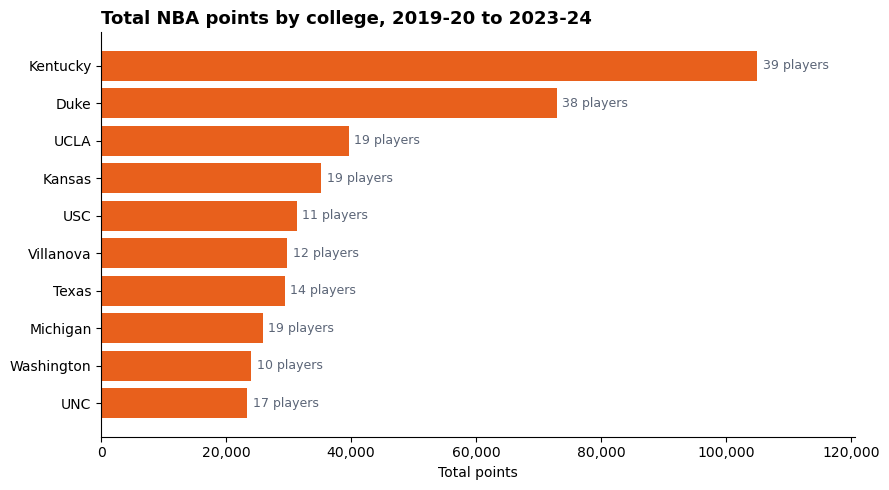

In [33]:
top = q1.head(10).sort_values("total_points")   # top 10, smallest first so the biggest bar ends up on top

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top["college"], top["total_points"], color="#E8601C")
ax.bar_label(bars, labels=[f"{n} players" for n in top["num_players"]],
             padding=4, fontsize=9, color="#5B6577")

ax.set_title("Total NBA points by college, 2019-20 to 2023-24", loc="left", fontsize=13, fontweight="bold")
ax.set_xlabel("Total points")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))   # 100000 -> 100,000
ax.set_xlim(0, top["total_points"].max() * 1.15)                # room for the labels
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("query1_chart.png", dpi=200)   # image file for your website
plt.show()

### Query 2 — Outside the US, which countries produce the most NBA points?

In [34]:
q2 = sql('''
SELECT p.birth_country,
       COUNT(DISTINCT p.id) AS num_players,
       SUM(ps.points)       AS total_points
FROM players p
JOIN player_stats ps ON ps.player_id = p.id
WHERE p.birth_country <> 'United States'
GROUP BY p.birth_country
HAVING COUNT(DISTINCT p.id) >= 5
ORDER BY total_points DESC;''')
q2

,birth_country,num_players,total_points
0,Canada,33,59271
1,Australia,15,20254
2,Serbia,9,17950
3,Germany,7,16848
4,France,23,16712
5,Bosnia and Herzegovina,5,12761
6,Italy,7,8879
7,Spain,6,6582
8,Turkey,5,6194
9,Nigeria,6,4910


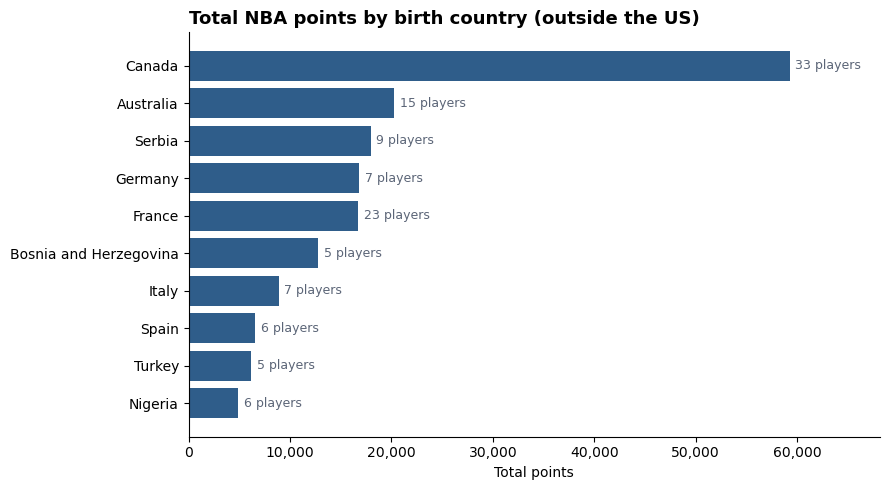

In [35]:
top = q2.head(10).sort_values("total_points")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top["birth_country"], top["total_points"], color="#2F5D8A")
ax.bar_label(bars, labels=[f"{n} players" for n in top["num_players"]],
             padding=4, fontsize=9, color="#5B6577")

ax.set_title("Total NBA points by birth country (outside the US)", loc="left", fontsize=13, fontweight="bold")
ax.set_xlabel("Total points")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_xlim(0, top["total_points"].max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("query2_chart.png", dpi=200)
plt.show()

### Query 3 — Which coach's team scored the most points in a single season?

In [36]:
q3 = sql('''
SELECT ts.coach || ' (' || t.abbr_name || ', ' || s.season_name || ')' AS coach_team_season,
       COUNT(ps.id)   AS players_used,
       SUM(ps.points) AS team_points
FROM player_stats ps
JOIN team_seasons ts ON ts.team_id   = ps.team_id
                    AND ts.season_id = ps.season_id
JOIN teams   t ON t.id = ps.team_id
JOIN seasons s ON s.id = ps.season_id
WHERE ps.multi_team_flag = 0
GROUP BY ts.id
ORDER BY team_points DESC
LIMIT 10;''')
q3

,coach_team_season,players_used,team_points
0,"Mike Brown (SAC, 2022-23)",19,9813
1,"Joe Mazzulla (BOS, 2023-24)",15,9663
2,"Steve Kerr (GSW, 2023-24)",18,9657
3,"Quin Snyder (ATL, 2023-24)",17,9624
4,"Steve Kerr (GSW, 2022-23)",16,9568
5,"Mike Brown (SAC, 2023-24)",19,9555
6,"Joe Mazzulla (BOS, 2022-23)",16,9548
7,"Taylor Jenkins (MEM, 2021-22)",22,9480
8,"Chris Finch (MIN, 2021-22)",16,9478
9,"Mark Daigneault (OKC, 2023-24)",15,9470


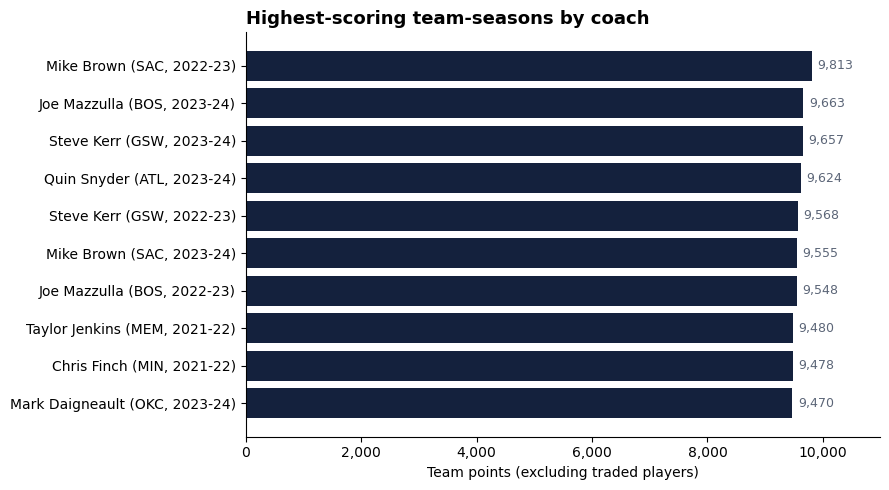

In [37]:
top = q3.sort_values("team_points")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top["coach_team_season"], top["team_points"], color="#14213D")
ax.bar_label(bars, labels=[f"{p:,}" for p in top["team_points"]],
             padding=4, fontsize=9, color="#5B6577")

ax.set_title("Highest-scoring team-seasons by coach", loc="left", fontsize=13, fontweight="bold")
ax.set_xlabel("Team points (excluding traded players)")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_xlim(0, top["team_points"].max() * 1.12)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("query3_chart.png", dpi=200)
plt.show()